# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks IV: Network in Network, All Convolutional Net

<br/>
Jiří Fejlek

2026-02-19
<br/>


We will continue our series on convolutional networks by looking at convolutional networks without fully connected layers. These fully connected layers (used as classification layers), included in CNNs such as AlexNet [[1](#1)] and VGGNet [[2](#2)], dramatically increase the network's parameter count (we recall that AlexNet has 60 million parameters and VGGNet-11 has over 120 million parameters). It turns out we can significantly reduce a convolutional network's parameter count by omitting these fully connected layers while mostly preserving its overall performance. 

## Table of Contents

- [Network in Network](#nin)
  - [Training NiN on Fashion-MNIST](#nin_fashion_mnist)
- [All Convolutional Net](#acn)
- [References](#references)

## Network in Network <a class="anchor" id="nin"></a>

The first convolutional network we will have a look at is the Network in Network CNN from 2014 [[3](#3)]. This network contains two important design elements that we will encounter in later CNNs. First, it uses a convolution layer combined with an average pooling layer for classification instead of a stack of fully connected layers, i.e., the final "smoothed" images obtained from the convolutional layers are simply averaged to a single pixel (i.e, single number) that will serve as the final features for classification.

The second important design element is the inclusion of 1x1 convolutional layers. It would seem that such convolutions would not achieve much. However, they serve two purposes. They allow us to control (increase or decrease) the number of *channels* (i.e., the number of "figures") between convolution layers and increase the network's nonlinearity (each convolution is followed by an activation function). Most importantly, they achieve both goals using a very low parameter count. 


The Network in Network (NiN) blocks consist of a convolution layer followed by two 1x1 convolutions in series. 

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [3]:
def NIN_block(out_channels, kernel_size, stride, padding):
    return nn.Sequential(
    nn.LazyConv2d(out_channels, kernel_size, stride, padding), nn.ReLU(),
    nn.LazyConv2d(out_channels, kernel_size = 1), nn.ReLU(),
    nn.LazyConv2d(out_channels, kernel_size = 1), nn.ReLU())

Let us implement a "Network in Network version" of AlexNet [[1](#1)] by replacing the convolution layers with a NiN block. We will also remove the fully conntected layers and replace them with a convolution layer and average pooling.

In [4]:
class NiN_alexnet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.net_stack = nn.Sequential(
            NIN_block(96, kernel_size = 11, stride = 4, padding = 1), 
            nn.MaxPool2d(3, stride = 2), nn.Dropout2d(0.0),
            NIN_block(256, kernel_size = 5, stride = 1, padding = 2), 
            nn.MaxPool2d(3, stride = 2), nn.Dropout2d(0.0),
            NIN_block(384, kernel_size = 3, stride = 1, padding = 1), 
            nn.MaxPool2d(3, stride = 2), nn.Dropout2d(0.25),
            NIN_block(num_classes, kernel_size = 3, stride = 1, padding = 1),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [5]:
layer_summary(NiN_alexnet(10),(1, 1, 227, 227))

Sequential output shape:	 torch.Size([1, 96, 55, 55])
MaxPool2d output shape:	 torch.Size([1, 96, 27, 27])
Dropout2d output shape:	 torch.Size([1, 96, 27, 27])
Sequential output shape:	 torch.Size([1, 256, 27, 27])
MaxPool2d output shape:	 torch.Size([1, 256, 13, 13])
Dropout2d output shape:	 torch.Size([1, 256, 13, 13])
Sequential output shape:	 torch.Size([1, 384, 13, 13])
MaxPool2d output shape:	 torch.Size([1, 384, 6, 6])
Dropout2d output shape:	 torch.Size([1, 384, 6, 6])
Sequential output shape:	 torch.Size([1, 10, 6, 6])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


Let us put together the training loop. 

In [6]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [7]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)  

In [8]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

### Training NiN on Fashion-MNIST <a class="anchor" id="nin_fashion_mnist"></a>

Let us train our Network in Network on the Fashion-MNIST dataset [[4](#4)].

In [9]:
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([227,227]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 500, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

In [10]:
NiN_Alex_cuda = NiN_alexnet(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
NiN_Alex_cuda(x);

We observe that our NiN version of AlexNet has significantly fewer parameters than the original.

In [11]:
sum(p.numel() for p in NiN_Alex_cuda.parameters() if p.requires_grad)

1992166

The performance of the model on the upscaled images is as follows.

In [12]:
NiN_Alex_cuda = NiN_alexnet(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
NiN_Alex_cuda(x);

torch.manual_seed(123)
NiN_Alex_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(NiN_Alex_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, NiN_Alex_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1717.0223443508148


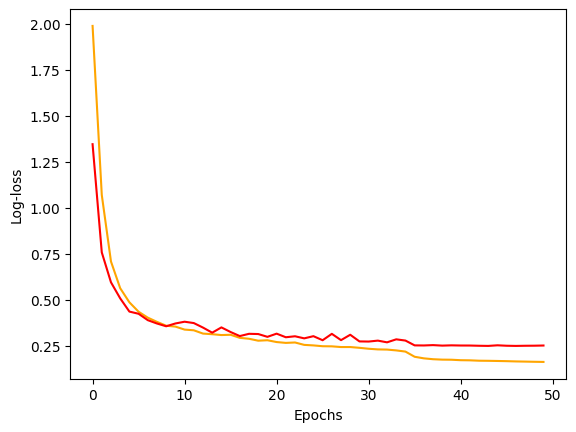

In [13]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

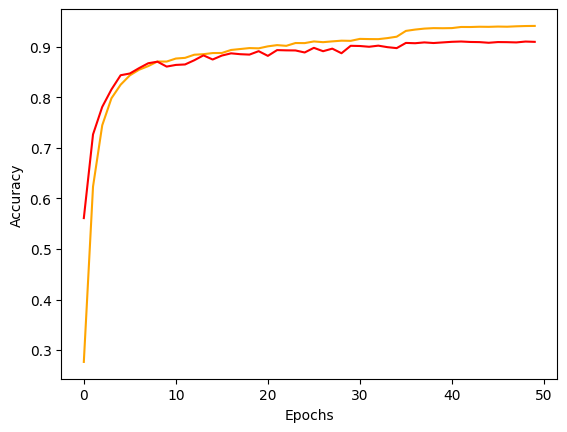

In [14]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

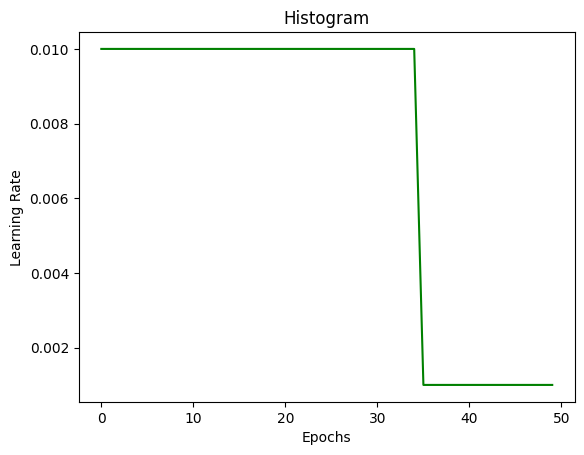

In [15]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [16]:
accu_epochs_train[49]

0.941016674041748

In [17]:
accu_epochs_test[49]

0.909500002861023

We have achieved slightly worse performance than with full-sized AlexNet (92.1%). Let us try to do better by designing a VGGNet-like network next.

In [18]:
def VGG_nin_block(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size = 3, padding = 1))
        layers.append(nn.ReLU())
    layers.append(nn.LazyConv2d(out_channels, kernel_size = 1))
    layers.append(nn.ReLU())
    layers.append(nn.LazyConv2d(out_channels, kernel_size = 1))
    layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size = 2,stride = 2))
    return nn.Sequential(*layers)

In [19]:
class VGG_nin(nn.Module):
    def __init__(self, VGG_arch, num_classes):
        super().__init__()
        
        vgg_nin_blocks = []
        for (num_convs, out_channels) in VGG_arch:
            vgg_nin_blocks.append(VGG_nin_block(num_convs, out_channels))
            
        self.net_stack = nn.Sequential(
            *vgg_nin_blocks, 
            NIN_block(num_classes, kernel_size = 3, stride = 1, padding = 1), nn.Dropout2d(0.1),
            nn.AdaptiveAvgPool2d((1, 1)), 
            nn.Flatten()
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

We will use the VGGNet's modular design to create a network better suited to the size of FashionMNIST images.

In [20]:
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([28,28]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

In [21]:
layer_summary(VGG_nin(((2,64),(2,128),(2,256)), num_classes = 10),(1,1,28,28))

Sequential output shape:	 torch.Size([1, 64, 14, 14])
Sequential output shape:	 torch.Size([1, 128, 7, 7])
Sequential output shape:	 torch.Size([1, 256, 3, 3])
Sequential output shape:	 torch.Size([1, 10, 3, 3])
Dropout2d output shape:	 torch.Size([1, 10, 3, 3])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


In [22]:
cuda_device = torch.device('cuda')
VGGNet11_nin_cuda = VGG_nin(VGG_arch = ((2,64),(2,128),(2,256)), num_classes = 10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
VGGNet11_nin_cuda(x);

In [23]:
VGGNet11_nin_cuda

VGG_nin(
  (net_stack): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (5): ReLU()
      (6): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv

In [24]:
sum(p.numel() for p in VGGNet11_nin_cuda.parameters() if p.requires_grad)

1340454

In [25]:
fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

torch.manual_seed(123)
VGGNet11_nin_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(VGGNet11_nin_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones= [35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, VGGNet11_nin_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

649.4371819496155


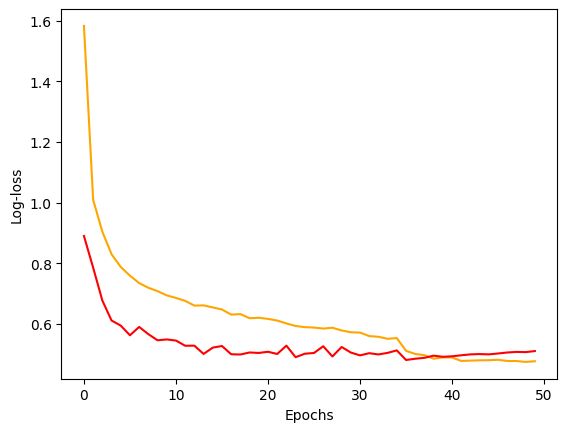

In [26]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

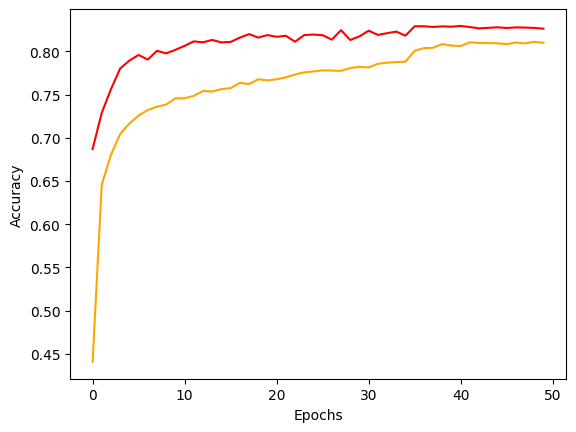

In [27]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [28]:
accu_epochs_train[49]

0.8100666999816895

In [29]:
accu_epochs_test[49]

0.8263999819755554

The perfromance is pretty bad. Let us try to improve it by incorporating image augmentation and batch normalization. 

In [30]:
def VGG_nin_block_bn(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size = 3, padding = 1))
        layers.append(nn.LazyBatchNorm2d())
        layers.append(nn.ReLU())
        
    layers.append(nn.LazyConv2d(out_channels, kernel_size = 1))
    layers.append(nn.LazyBatchNorm2d())
    layers.append(nn.ReLU())
    layers.append(nn.LazyConv2d(out_channels, kernel_size = 1))
    layers.append(nn.LazyBatchNorm2d())
    layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size = 2,stride = 2))
    return nn.Sequential(*layers)

In [31]:
def NIN_block_bn(out_channels, kernel_size, stride, padding):
    return nn.Sequential(
    nn.LazyConv2d(out_channels, kernel_size, stride, padding), nn.LazyBatchNorm2d(), nn.ReLU(),
    nn.LazyConv2d(out_channels, kernel_size = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
    nn.LazyConv2d(out_channels, kernel_size = 1), nn.LazyBatchNorm2d(), nn.ReLU())

In [32]:
class VGG_nin_bn(nn.Module):
    def __init__(self, VGG_arch, num_classes):
        super().__init__()
        
        vgg_nin_blocks = []
        for (num_convs, out_channels) in VGG_arch:
            vgg_nin_blocks.append(VGG_nin_block_bn(num_convs, out_channels))
            
        self.net_stack = nn.Sequential(
            *vgg_nin_blocks, 
            NIN_block_bn(num_classes, kernel_size = 3, stride = 1, padding = 1), nn.Dropout2d(0.1),
            nn.AdaptiveAvgPool2d((1, 1)), 
            nn.Flatten()
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [33]:
cuda_device = torch.device('cuda')
VGGNet11_nin_bn_cuda = VGG_nin_bn(VGG_arch = ((2,64),(2,128),(2,256)), num_classes = 10).to(cuda_device).eval()

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
VGGNet11_nin_bn_cuda(x);

In [34]:
VGGNet11_nin_bn_cuda

VGG_nin_bn(
  (net_stack): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
      (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-

In [35]:
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = True) 

In [36]:
torch.manual_seed(123)
VGGNet11_nin_bn_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(VGGNet11_nin_bn_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, VGGNet11_nin_bn_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1432.8069455623627


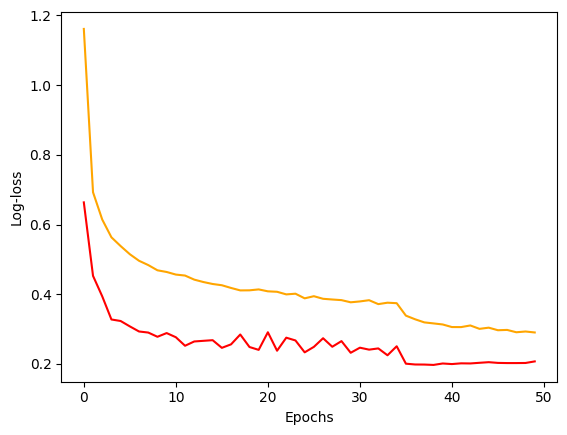

In [37]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

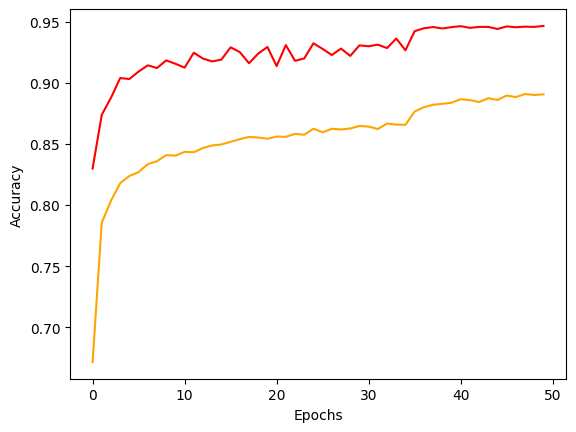

In [38]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [39]:
accu_epochs_test[49]

0.946399986743927

The accuracy improved dramatically. This performance is slightly better than the VGGNet architecture we have designed in the last project even though this model has about ten times lower number of parameters (about 1.3 million vs over 17 million).

## All Convolutional Net <a class="anchor" id="acn"></a>

The second architecture we will explore is the All Convolutional Net (ACN) from 2015 [[5](#5)], which achieved competitive performance on CIFAR-10 (and CIFAR-100) at the time despite its simple all-convolutional design. The architecture does not really contain any new elements that we have not encountered before. One minor thing is using convolutional layers for downsampling instead of pooling layers, a design element that shows up in later CNNs as well.

In [40]:
class all_conv_net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.net_stack = nn.Sequential(
            nn.LazyConv2d(96, kernel_size = 3, stride = 1, padding = 1), nn.ReLU(), 
            nn.LazyConv2d(96, kernel_size = 3, stride = 1, padding = 1), nn.ReLU(), 
            nn.LazyConv2d(96, kernel_size = 3, stride = 2, padding = 1), nn.ReLU(), 
            
            nn.LazyConv2d(192, kernel_size = 3, stride = 1, padding = 1), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size = 3, stride = 1, padding = 1), nn.ReLU(), 
            nn.LazyConv2d(192, kernel_size = 3, stride = 2, padding = 1), nn.ReLU(), 

            nn.Dropout2d(0.1),

            nn.LazyConv2d(192, kernel_size = 3, stride = 1, padding = 1), nn.ReLU(), 
            nn.LazyConv2d(192, kernel_size = 1, stride = 1), nn.ReLU(), 
            nn.LazyConv2d(num_classes, kernel_size = 1, stride = 1, padding = 0), nn.ReLU(), 
            
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [41]:
layer_summary(all_conv_net(10),(1, 3, 32, 32))

Conv2d output shape:	 torch.Size([1, 96, 32, 32])
ReLU output shape:	 torch.Size([1, 96, 32, 32])
Conv2d output shape:	 torch.Size([1, 96, 32, 32])
ReLU output shape:	 torch.Size([1, 96, 32, 32])
Conv2d output shape:	 torch.Size([1, 96, 16, 16])
ReLU output shape:	 torch.Size([1, 96, 16, 16])
Conv2d output shape:	 torch.Size([1, 192, 16, 16])
ReLU output shape:	 torch.Size([1, 192, 16, 16])
Conv2d output shape:	 torch.Size([1, 192, 16, 16])
ReLU output shape:	 torch.Size([1, 192, 16, 16])
Conv2d output shape:	 torch.Size([1, 192, 8, 8])
ReLU output shape:	 torch.Size([1, 192, 8, 8])
Dropout2d output shape:	 torch.Size([1, 192, 8, 8])
Conv2d output shape:	 torch.Size([1, 192, 8, 8])
ReLU output shape:	 torch.Size([1, 192, 8, 8])
Conv2d output shape:	 torch.Size([1, 192, 8, 8])
ReLU output shape:	 torch.Size([1, 192, 8, 8])
Conv2d output shape:	 torch.Size([1, 10, 8, 8])
ReLU output shape:	 torch.Size([1, 10, 8, 8])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten outpu

Let us train ACN on CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html).

In [42]:
transforms_cifar10 =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10)

g = torch.Generator()
g.manual_seed(0)
cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True,generator=g) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False,generator=g)

In [43]:
all_conv = all_conv_net(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
all_conv(x);

The number of parameters is again very small in comparison to earlier networks such as AlexNet or VGGNet-11.

In [44]:
sum(p.numel() for p in all_conv.parameters() if p.requires_grad)

1369738

In [45]:
torch.manual_seed(123)

all_conv = all_conv_net(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]

all_conv(x);
all_conv.apply(init_weights_he) 

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = False) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

optim_SGD_cuda =  torch.optim.SGD(all_conv.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, all_conv, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1138.9709129333496


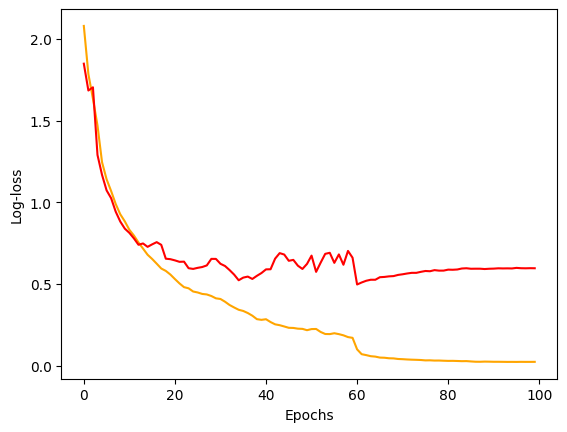

In [46]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

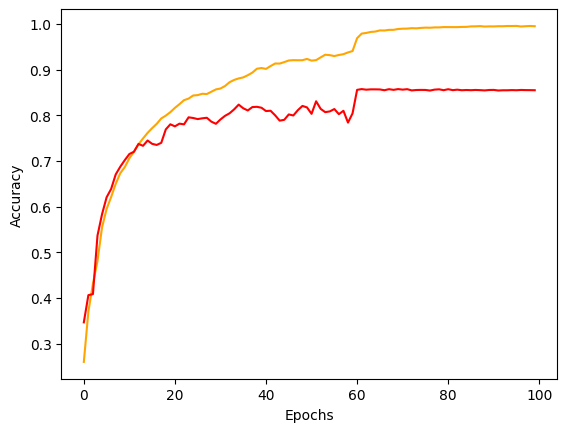

In [47]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

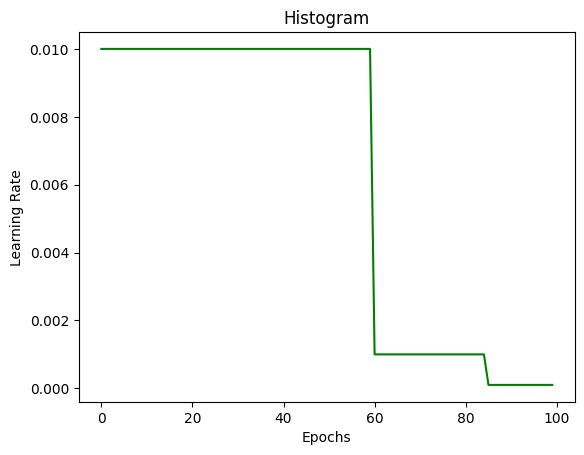

In [48]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [49]:
accu_epochs_train[99]

0.9953999519348145

In [50]:
accu_epochs_test[99]

0.8551999926567078

The performance of ACN is similar to our VGGNet models without batch normalization. Let's consider image augmentation and batch normalization next.

In [51]:
class all_conv_net_bn(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.net_stack = nn.Sequential(
            nn.LazyConv2d(96, kernel_size = 3, stride = 1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(96, kernel_size = 3, stride = 1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(96, kernel_size = 3, stride = 2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            
            nn.LazyConv2d(192, kernel_size = 3, stride = 1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size = 3, stride = 1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(192, kernel_size = 3, stride = 2, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 

            nn.Dropout2d(0.25),

            nn.LazyConv2d(192, kernel_size = 3, stride = 1, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(192, kernel_size = 1, stride = 1), nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(num_classes, kernel_size = 1, stride = 1, padding = 0), nn.ReLU(), 
            
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [52]:
torch.manual_seed(123)

all_conv_bn = all_conv_net_bn(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]

all_conv_bn(x);
all_conv_bn.apply(init_weights_he) 

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8,1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = False) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

optim_SGD_cuda =  torch.optim.SGD(all_conv_bn.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, all_conv_bn, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2583.5119535923004


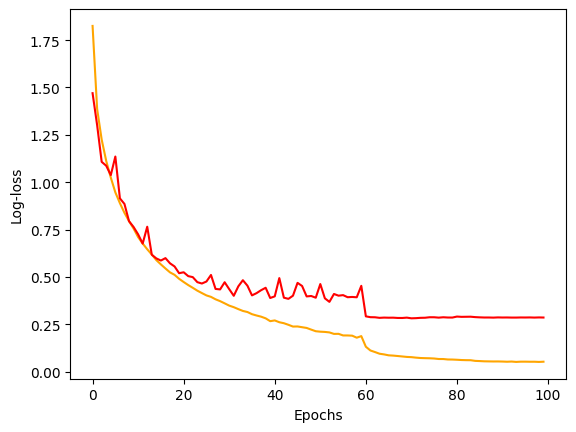

In [53]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

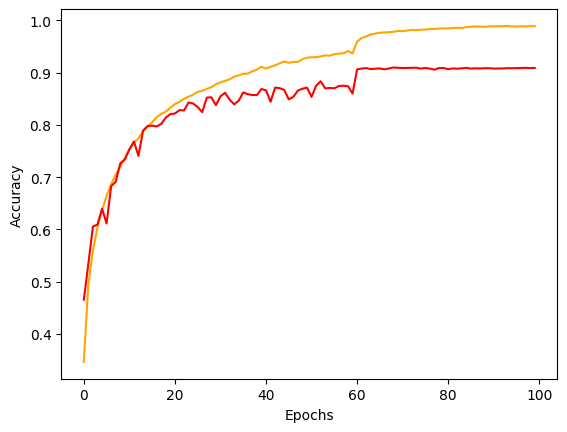

In [54]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

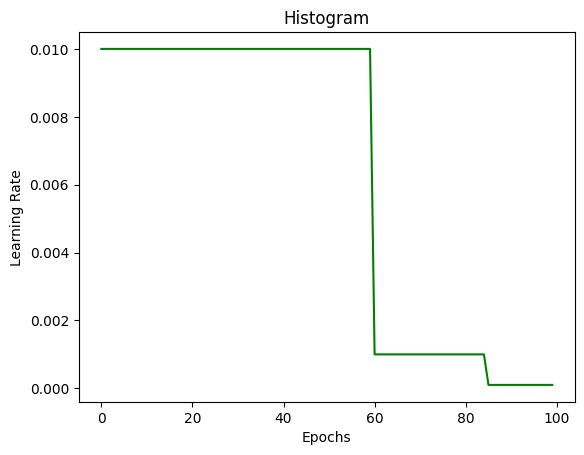

In [55]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [56]:
accu_epochs_train[99]

0.9888799786567688

In [57]:
accu_epochs_test[99]

0.9089999794960022

We performed about 2.5% worse than with the VGGnet architecture.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> KRIZHEVSKY, Alex; SUTSKEVER, Ilya; HINTON, Geoffrey E. Imagenet classification with deep convolutional neural networks. *Advances in neural information processing systems*, 2012, 25.

<a id="2">[2]</a> SIMONYAN, Karen; ZISSERMAN, Andrew. Very deep convolutional networks for large-scale image recognition. *arXiv preprint arXiv:1409.1556*, 2014.

<a id="3">[3]</a> LIN, Min; CHEN, Qiang; YAN, Shuicheng. Network in network. arXiv preprint arXiv:1312.4400, 2013.

<a id="4">[4]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.

<a id="5">[5]</a> SPRINGENBERG, Jost Tobias, et al. Striving for simplicity: The all convolutional net. arXiv 2014. arXiv preprint arXiv:1412.6806, 2014.